In [43]:
import polars as pl

df_raw = pl.read_parquet("../parquets/B_dreamdex_weth_top_of_book.parquet")
df = df_raw.unique().sort("seq_id")

pl.DataFrame({
    "stage": ["raw", "deduped_and_seq_sorted"],
    "rows": [df_raw.height, df.height],
    "columns": [df_raw.width, df.width],
})

stage,rows,columns
str,i64,i64
"""raw""",6988,9
"""deduped_and_seq_sorted""",6988,9


In [44]:
df.null_count()

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,6988,6988,0,1540,1540,0,0


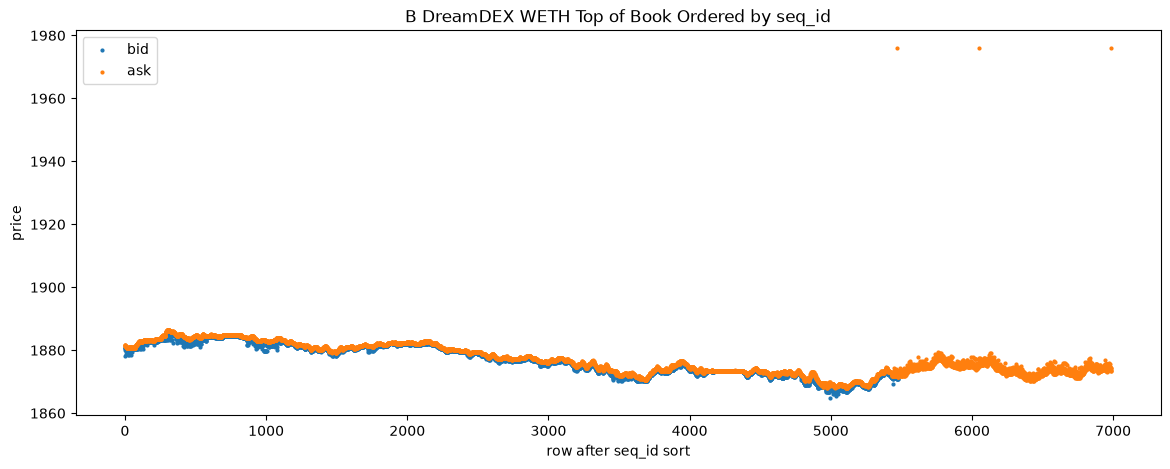

In [45]:
import polars as pl
import matplotlib.pyplot as plt

df_raw = pl.read_parquet("../parquets/B_dreamdex_weth_top_of_book.parquet")
df = df_raw.unique().sort("seq_id")

df_seq = df.with_row_index("row")

plt.figure(figsize=(14, 5))
plt.scatter(df_seq["row"], df_seq["bid_price"], s=4, label="bid")
plt.scatter(df_seq["row"], df_seq["ask_price"], s=4, label="ask")
plt.title("B DreamDEX WETH Top of Book Ordered by seq_id")
plt.xlabel("row after seq_id sort")
plt.ylabel("price")
plt.legend()
plt.show()

In [46]:
df = df.with_columns(
    missing_bid=pl.col("bid_price").is_null() | pl.col("bid_qty").is_null(),
    missing_ask=pl.col("ask_price").is_null() | pl.col("ask_qty").is_null(),
).with_columns(
    quote_state=
        pl.when(pl.col("missing_bid") & pl.col("missing_ask")).then(pl.lit("no_bbo"))
        .when(pl.col("missing_bid")).then(pl.lit("ask_only"))
        .when(pl.col("missing_ask")).then(pl.lit("bid_only"))
        .otherwise(pl.lit("two_sided"))
)

df.group_by("quote_state").len()

quote_state,len
str,u32
"""ask_only""",1540
"""two_sided""",5448


In [47]:
df_raw.shape, df_raw.unique().shape

((6988, 9), (6988, 9))

In [48]:
df.group_by("seq_id").len().filter(pl.col("len") > 1)

seq_id,len
i64,u32


In [49]:
for col in ["ingress_ts", "transaction_ts", "publish_ts"]:
    dupes = df.filter(pl.col(col).is_not_null()).group_by(col).len().filter(pl.col("len") > 1)
    print(col, "duplicate values:", dupes.height, "rows involved:", dupes["len"].sum())

ingress_ts duplicate values: 0 rows involved: 0
transaction_ts duplicate values: 0 rows involved: 0
publish_ts duplicate values: 0 rows involved: 0


In [50]:
df = df.sort("seq_id").with_columns(
    same_bbo_as_prev=(
        (pl.col("bid_price") == pl.col("bid_price").shift(1))
        & (pl.col("bid_qty") == pl.col("bid_qty").shift(1))
        & (pl.col("ask_price") == pl.col("ask_price").shift(1))
        & (pl.col("ask_qty") == pl.col("ask_qty").shift(1))
    )
)

df.select(pl.col("same_bbo_as_prev").sum().alias("same_bbo_as_prev_count"))

same_bbo_as_prev_count
u32
0


In [51]:
df.sort("seq_id").select(
    pl.col("ingress_ts").is_sorted().alias("ingress_monotonic")
)

ingress_monotonic
bool
true


In [52]:
df = df.with_columns(
    spread=pl.col("ask_price") - pl.col("bid_price"),
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
)

df.select(
    pl.col("crossed_book").sum().alias("crossed_book_count"),
    pl.col("locked_book").sum().alias("locked_book_count"),
)

crossed_book_count,locked_book_count
u32,u32
0,0


In [53]:
df.filter(
    (pl.col("bid_price") <= 0)
    | (pl.col("ask_price") <= 0)
    | (pl.col("bid_qty") <= 0)
    | (pl.col("ask_qty") <= 0)
)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,missing_bid,missing_ask,quote_state,same_bbo_as_prev,spread,crossed_book,locked_book
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool,str,bool,f64,bool,bool


In [54]:
df = df.with_columns(
    mid=(pl.col("bid_price") + pl.col("ask_price")) / 2
)

df = df.with_columns(
    spread_pct=pl.col("spread") / pl.col("mid") * 100
)
df.select(
    pl.col("spread_pct").quantile(0.99).alias("p99_spread_pct"),
    pl.col("spread_pct").max().alias("max_spread_pct"),
)

p99_spread_pct,max_spread_pct
f64,f64
0.132726,0.270437


In [55]:
df.sort("bid_price", nulls_last=True).select("ingress_ts", "seq_id", "bid_price", "bid_qty", "ask_price").head(10)

ingress_ts,seq_id,bid_price,bid_qty,ask_price
"datetime[μs, UTC]",i64,f64,f64,f64
2026-08-14 08:24:30.399098 UTC,7722759,1864.82,4.4835,1869.87
2026-08-14 08:24:59.293602 UTC,7722851,1865.46,4.4775,1868.59
2026-08-14 08:24:47.296572 UTC,7722807,1866.1,4.536,1869.23
2026-08-14 08:24:52.393197 UTC,7722824,1866.1,4.536,1868.59
2026-08-14 08:25:20.392434 UTC,7722885,1866.1,4.4919,1868.59
2026-08-14 08:24:52.589468 UTC,7722833,1866.6,0.1358,1868.59
2026-08-14 08:24:54.190245 UTC,7722840,1866.6,0.1358,1868.59
2026-08-14 08:24:58.591655 UTC,7722844,1866.6,0.1358,1868.59
2026-08-14 08:24:59.293578 UTC,7722848,1866.6,0.1358,1868.59


In [56]:
df.sort("ask_price", descending=True, nulls_last=True).select("ingress_ts", "seq_id", "bid_price", "ask_price", "ask_qty").head(10)

ingress_ts,seq_id,bid_price,ask_price,ask_qty
"datetime[μs, UTC]",i64,f64,f64,f64
2026-08-14 08:42:07.059292 UTC,7724681,null,1976.0,0.0097
2026-08-14 09:21:30.309469 UTC,7726496,null,1976.0,0.0097
2026-08-14 10:13:26.437420 UTC,7728985,null,1976.0,0.0097
2026-08-14 04:16:50.470066 UTC,7698634,1885.87,1886.43,4.4235
2026-08-14 04:17:05.268219 UTC,7698653,1884.93,1886.43,4.4235
2026-08-14 04:17:05.268248 UTC,7698654,1885.86,1886.43,4.4235
2026-08-14 04:17:08.470861 UTC,7698659,1884.93,1886.43,4.4235
2026-08-14 04:17:08.470875 UTC,7698661,1883.98,1886.43,4.4235
2026-08-14 04:17:08.470914 UTC,7698662,1885.6,1886.43,4.4235


In [57]:
df.sort("seq_id").with_columns(previous_ask=pl.col("ask_price").shift(1), next_ask=pl.col("ask_price").shift(-1)).sort("ask_price", descending=True).head(3).select("ingress_ts", "seq_id", "ask_price", "ask_qty", "previous_ask", "next_ask")

ingress_ts,seq_id,ask_price,ask_qty,previous_ask,next_ask
"datetime[μs, UTC]",i64,f64,f64,f64,f64
2026-08-14 08:42:07.059292 UTC,7724681,1976.0,0.0097,1874.06,1871.88
2026-08-14 09:21:30.309469 UTC,7726496,1976.0,0.0097,1877.53,1875.54
2026-08-14 10:13:26.437420 UTC,7728985,1976.0,0.0097,1875.72,1873.41


In [58]:
df = df.with_columns(ask_price_candidate=pl.col("seq_id").is_in([7724681, 7726496, 7728985]))

In [59]:
df.sort("bid_price", descending=True, nulls_last=True).select("ingress_ts", "seq_id", "bid_price", "bid_qty", "ask_price").head(10)

ingress_ts,seq_id,bid_price,bid_qty,ask_price
"datetime[μs, UTC]",i64,f64,f64,f64
2026-08-14 04:16:49.982381 UTC,7698632,1885.87,0.0302,1886.27
2026-08-14 04:16:50.470066 UTC,7698634,1885.87,0.0302,1886.43
2026-08-14 04:17:05.268248 UTC,7698654,1885.86,0.0302,1886.43
2026-08-14 04:16:46.670120 UTC,7698628,1885.7,0.0302,1886.27
2026-08-14 04:16:43.369738 UTC,7698620,1885.62,0.0302,1886.27
2026-08-14 04:17:39.270956 UTC,7698735,1885.61,0.0302,1885.69
2026-08-14 04:17:08.470914 UTC,7698662,1885.6,0.0302,1886.43
2026-08-14 04:17:08.471011 UTC,7698663,1885.6,0.0302,1886.37
2026-08-14 04:17:08.770280 UTC,7698666,1885.6,0.0302,1886.11


In [60]:
df.sort("ask_price", descending=False, nulls_last=True).select("ingress_ts", "seq_id", "ask_price", "ask_qty", "bid_price").head(10)

ingress_ts,seq_id,ask_price,ask_qty,bid_price
"datetime[μs, UTC]",i64,f64,f64,f64
2026-08-14 08:24:30.047209 UTC,7722716,1867.93,0.0664,1867.17
2026-08-14 08:26:49.193209 UTC,7723074,1867.95,4.4979,1867.41
2026-08-14 08:26:51.392122 UTC,7723076,1867.95,4.4979,1866.74
2026-08-14 08:26:51.392152 UTC,7723078,1867.95,4.4979,1867.32
2026-08-14 08:26:54.791375 UTC,7723082,1867.95,4.4979,1866.74
2026-08-14 08:26:54.791398 UTC,7723083,1867.95,4.4979,1867.44
2026-08-14 08:27:05.892044 UTC,7723091,1867.95,4.4979,1866.74
2026-08-14 08:27:05.892109 UTC,7723093,1867.95,4.4979,1867.58
2026-08-14 08:27:09.294376 UTC,7723095,1867.95,4.4979,1866.74


In [61]:
df = df.with_columns(
    microprice=(
        (pl.col("bid_price") * pl.col("ask_qty") + pl.col("ask_price") * pl.col("bid_qty"))
        / (pl.col("bid_qty") + pl.col("ask_qty"))
    )
)

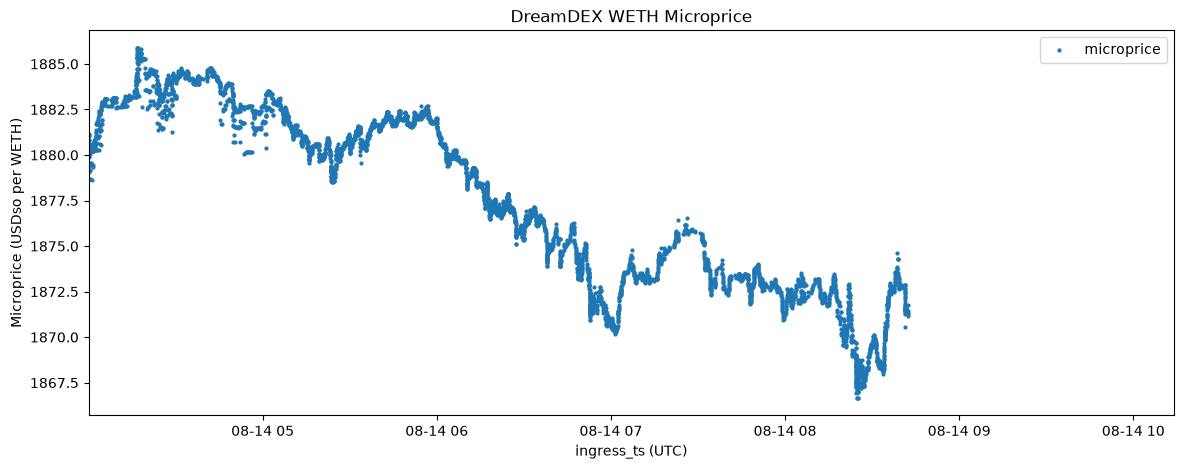

In [63]:
df_plot = df.sort("ingress_ts")

plt.figure(figsize=(14, 5))
plt.scatter(df_plot["ingress_ts"], df_plot["microprice"], s=4, label="microprice")
plt.xlim(df_plot["ingress_ts"].min(), df_plot["ingress_ts"].max())
plt.title("DreamDEX WETH Microprice")
plt.xlabel("ingress_ts (UTC)")
plt.ylabel("Microprice (USDso per WETH)")
plt.legend()
plt.show()